# Support Ticket Intelligence Demo

End-to-end pipeline that classifies and enriches support tickets using Snowflake AI functions
(AI_CLASSIFY, AI_COMPLETE) via Dynamic Tables.

See [docs/pipeline.md](../docs/pipeline.md) for the pipeline specification.

In [2]:
import os
from snowflake.snowpark import Session
import matplotlib.pyplot as plt

session = Session.builder.configs({
    "connection_name": os.getenv("SNOWFLAKE_CONNECTION_NAME") or "oregon_tp"
}).create()
session.sql("USE WAREHOUSE AI_WH").collect()
session.sql("USE SCHEMA SNOWCARE_DEMO.SUPPORT").collect()
print("Connected to SNOWCARE_DEMO.SUPPORT")

Connected to SNOWCARE_DEMO.SUPPORT


In [3]:
row_count = session.table("RAW_SUPPORT_TICKETS").count()
print(f"RAW_SUPPORT_TICKETS: {row_count} rows (loaded via sql/01_setup.sql)")

RAW_SUPPORT_TICKETS: 1000 rows (loaded via sql/01_setup.sql)


## Cost Estimate: AI_CLASSIFY

Based on ~2,000 tickets, ~500 tokens avg per ticket, 3 AI_CLASSIFY calls per ticket:
- **Input tokens**: ~3M total -> ~4.5 credits
- **Output tokens**: minimal (label string only)

> Note: Since Sep 2025, Cortex AI functions support **incremental refresh** in Dynamic Tables.
> With `REFRESH_MODE = AUTO` (default), Snowflake will choose incremental mode, so only new/changed
> rows are processed on subsequent refreshes — significantly reducing cost after the initial load.

In [4]:
session.sql("""
CREATE OR REPLACE DYNAMIC TABLE DT_TICKET_CLASSIFICATION
  WAREHOUSE = AI_WH
  TARGET_LAG = '1 day'
  REFRESH_MODE = INCREMENTAL
AS
SELECT
    t.*,
    AI_CLASSIFY(
        t.TICKET_DESCRIPTION,
        [
          {'label':'Billing',        'description':'Invoicing, charges, refunds, subscription changes'},
          {'label':'Authentication', 'description':'Login, SSO, password, session, permissions'},
          {'label':'Performance',    'description':'Slowness, timeouts, latency, degradation'},
          {'label':'UI/UX',          'description':'Dashboard display, usability, interface issues'},
          {'label':'Integrations',   'description':'API connectors, data sync, third-party tools'},
          {'label':'Data Platform',  'description':'Query engine, data pipeline, analytics processing'},
          {'label':'Security',       'description':'Encryption, compliance, vulnerability, access control'},
          {'label':'Other',          'description':'Does not fit any other category'}
        ],
        {'task_description': 'Classify this support ticket into the product category it belongs to'}
    ):labels[0]::VARCHAR AS PRODUCT_CATEGORY,

    AI_CLASSIFY(
        t.TICKET_DESCRIPTION,
        [
          {'label':'Bug',                 'description':'Software defect or broken functionality'},
          {'label':'Feature Request',     'description':'Request for new capability or enhancement'},
          {'label':'Configuration Issue', 'description':'Setup, settings, or config problem'},
          {'label':'Data Issue',          'description':'Wrong data, missing data, data corruption'},
          {'label':'Usage Question',      'description':'How-to question about using the product'},
          {'label':'Access Problem',      'description':'Cannot access a resource due to permissions'},
          {'label':'Unknown',             'description':'Cannot determine the issue type'}
        ],
        {'task_description': 'Classify this support ticket by the type of issue reported'}
    ):labels[0]::VARCHAR AS ISSUE_TYPE,

    AI_CLASSIFY(
        t.TICKET_DESCRIPTION,
        [
          {'label':'P0', 'description':'Critical outage affecting production or revenue'},
          {'label':'P1', 'description':'Major issue with significant business impact'},
          {'label':'P2', 'description':'Moderate issue with workaround available'},
          {'label':'P3', 'description':'Minor issue or cosmetic problem'}
        ],
        {'task_description': 'Assess the urgency of this support ticket based on business impact described'}
    ):labels[0]::VARCHAR AS PRIORITY_BUCKET
FROM RAW_SUPPORT_TICKETS t
""").collect()
print("DT_TICKET_CLASSIFICATION created")

DT_TICKET_CLASSIFICATION created


## Cost Estimate: AI_COMPLETE

Based on ~2,000 tickets, 3 AI_COMPLETE calls per ticket (claude-4-sonnet):
- **Input tokens**: ~3M -> ~4.5 credits
- **Output tokens**: ~600K -> ~4.5 credits
- **Total estimate**: ~9 credits for initial enrichment (incremental refreshes process only new rows)

In [6]:
session.sql("""
CREATE OR REPLACE DYNAMIC TABLE DT_TICKET_ENRICHMENT
  WAREHOUSE = AI_WH
  TARGET_LAG = '1 day'
  REFRESH_MODE = INCREMENTAL
AS
SELECT
    c.*,
    AI_COMPLETE(
        'claude-4-sonnet',
        'Summarize this support ticket in one sentence:\\n\\n' || c.TICKET_DESCRIPTION
    ) AS SUMMARY_TEXT,
    AI_COMPLETE(
        'claude-4-sonnet',
        'Explain briefly why this support ticket was classified as:\\n\\n'
            || 'product_category: ' || c.PRODUCT_CATEGORY || '\\n'
            || 'issue_type: '       || c.ISSUE_TYPE       || '\\n'
            || 'priority_bucket: '  || c.PRIORITY_BUCKET  || '\\n\\n'
            || 'Ticket:\\n' || c.TICKET_DESCRIPTION
    ) AS RATIONALE,
    AI_COMPLETE(
        'claude-4-sonnet',
        'Given this support ticket, suggest the next best action for a support manager:\\n\\n'
            || c.TICKET_DESCRIPTION
    ) AS MANAGER_RECOMMENDATION
FROM DT_TICKET_CLASSIFICATION c
""").collect()
print("DT_TICKET_ENRICHMENT created")

DT_TICKET_ENRICHMENT created


## Validation

Checks from [docs/pipeline.md](../docs/pipeline.md):
- Row counts match across pipeline stages
- Labels stay within taxonomy
- Key enrichment fields are populated
- Spot check sample records

In [7]:
for table in ['RAW_SUPPORT_TICKETS', 'DT_TICKET_CLASSIFICATION', 'DT_TICKET_ENRICHMENT']:
    count = session.table(table).count()
    print(f"{table}: {count} rows")

RAW_SUPPORT_TICKETS: 1000 rows
DT_TICKET_CLASSIFICATION: 1000 rows
DT_TICKET_ENRICHMENT: 1000 rows


In [8]:
df_labels = session.sql("""
    SELECT PRODUCT_CATEGORY, ISSUE_TYPE, PRIORITY_BUCKET, COUNT(*) AS CNT
    FROM DT_TICKET_CLASSIFICATION
    GROUP BY ALL ORDER BY CNT DESC
""").to_pandas()
display(df_labels)

,PRODUCT_CATEGORY,ISSUE_TYPE,PRIORITY_BUCKET,CNT
0,Billing,Data Issue,P1,89
1,Performance,Bug,P1,65
2,Performance,Bug,P0,59
3,Integrations,Bug,P1,57
4,Billing,Data Issue,P2,49
...,...,...,...,...
75,Authentication,Configuration Issue,P3,1
76,UI/UX,Access Problem,P2,1
77,Data Platform,Access Problem,P2,1
78,UI/UX,Access Problem,P1,1


In [9]:
df_nulls = session.sql("""
    SELECT
        COUNT_IF(SUMMARY_TEXT IS NULL) AS null_summary,
        COUNT_IF(RATIONALE IS NULL) AS null_rationale,
        COUNT_IF(MANAGER_RECOMMENDATION IS NULL) AS null_recommendation,
        COUNT(*) AS total
    FROM DT_TICKET_ENRICHMENT
""").to_pandas()
display(df_nulls)

,NULL_SUMMARY,NULL_RATIONALE,NULL_RECOMMENDATION,TOTAL
0,0,0,0,1000


## PM View: Product Category and Issue Trends

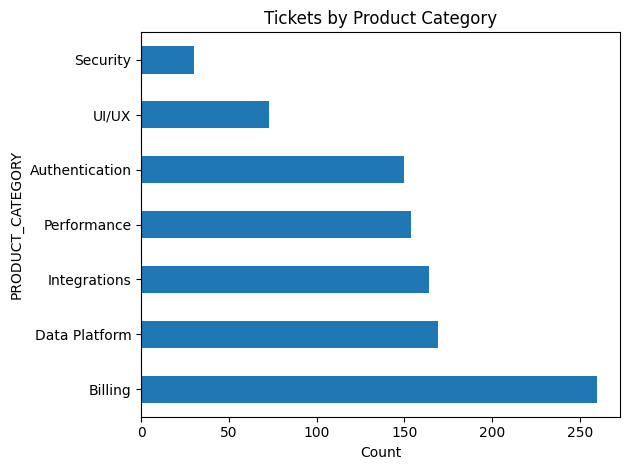

In [10]:
df_cat = session.sql("""
    SELECT PRODUCT_CATEGORY, COUNT(*) AS TICKET_COUNT
    FROM DT_TICKET_CLASSIFICATION
    GROUP BY PRODUCT_CATEGORY ORDER BY TICKET_COUNT DESC
""").to_pandas()
df_cat.plot.barh(x='PRODUCT_CATEGORY', y='TICKET_COUNT', legend=False)
plt.title('Tickets by Product Category')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

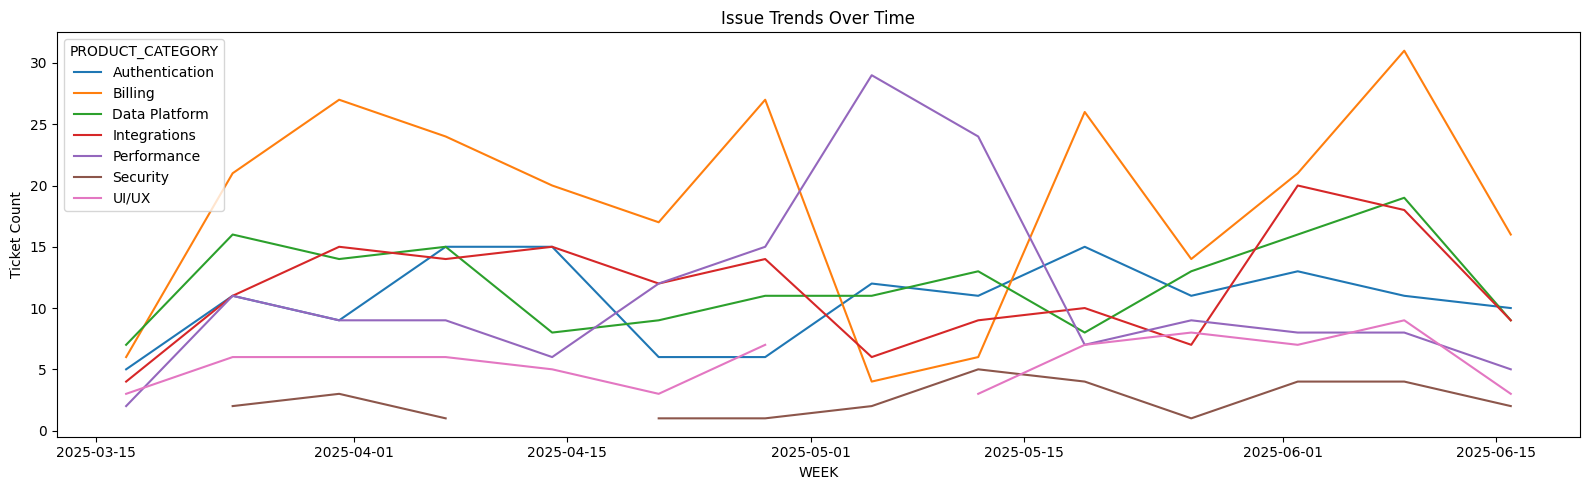

In [14]:
df_trend = session.sql("""
    SELECT DATE_TRUNC('WEEK', SUBMIT_DATE) AS WEEK, PRODUCT_CATEGORY, COUNT(*) AS CNT
    FROM DT_TICKET_CLASSIFICATION
    GROUP BY ALL ORDER BY WEEK
""").to_pandas()
df_trend.pivot(index='WEEK', columns='PRODUCT_CATEGORY', values='CNT').plot(figsize=(16, 5))
plt.title('Issue Trends Over Time')
plt.ylabel('Ticket Count')
plt.tight_layout()
plt.show()

## Support Manager View: Priority Distribution and P0/P1 Trends

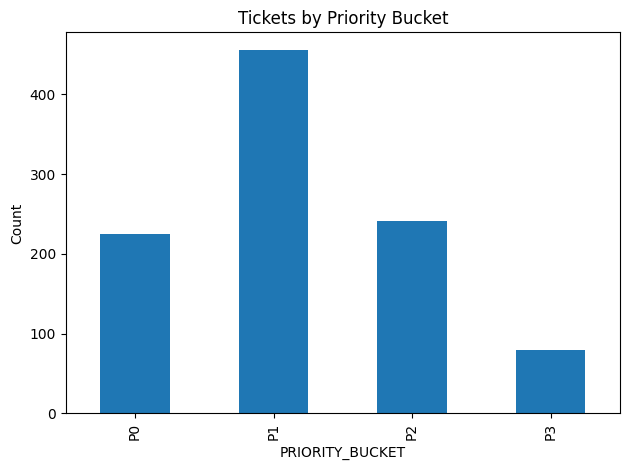

In [15]:
df_pri = session.sql("""
    SELECT PRIORITY_BUCKET, COUNT(*) AS TICKET_COUNT
    FROM DT_TICKET_CLASSIFICATION
    GROUP BY PRIORITY_BUCKET ORDER BY PRIORITY_BUCKET
""").to_pandas()
df_pri.plot.bar(x='PRIORITY_BUCKET', y='TICKET_COUNT', legend=False)
plt.title('Tickets by Priority Bucket')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

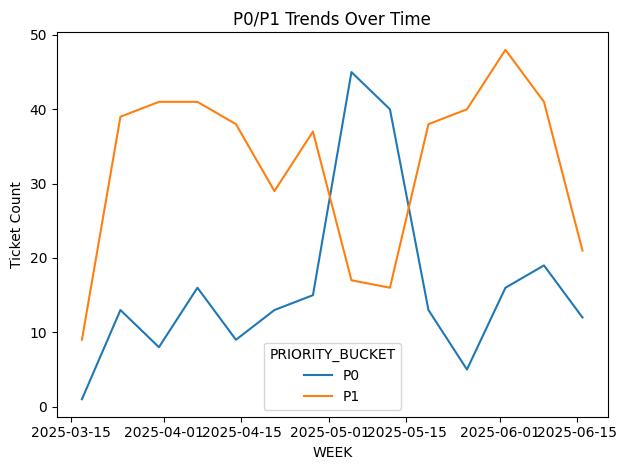

In [16]:
df_high = session.sql("""
    SELECT DATE_TRUNC('WEEK', SUBMIT_DATE) AS WEEK, PRIORITY_BUCKET, COUNT(*) AS CNT
    FROM DT_TICKET_CLASSIFICATION
    WHERE PRIORITY_BUCKET IN ('P0','P1')
    GROUP BY ALL ORDER BY WEEK
""").to_pandas()
df_high.pivot(index='WEEK', columns='PRIORITY_BUCKET', values='CNT').plot()
plt.title('P0/P1 Trends Over Time')
plt.ylabel('Ticket Count')
plt.tight_layout()
plt.show()

## Sample Enriched Records

In [17]:
df_samples = session.sql("""
    SELECT TICKET_ID, TICKET_SUBJECT, PRODUCT_CATEGORY, ISSUE_TYPE, PRIORITY_BUCKET,
           SUMMARY_TEXT, RATIONALE, MANAGER_RECOMMENDATION
    FROM DT_TICKET_ENRICHMENT
    LIMIT 5
""").to_pandas()
for _, row in df_samples.iterrows():
    print(f"--- {row['TICKET_ID']}: {row['TICKET_SUBJECT']} ---")
    print(f"Classification: {row['PRODUCT_CATEGORY']} / {row['ISSUE_TYPE']} / {row['PRIORITY_BUCKET']}")
    print(f"Summary: {row['SUMMARY_TEXT']}")
    print(f"Rationale: {row['RATIONALE']}")
    print(f"Recommendation: {row['MANAGER_RECOMMENDATION']}\n")

--- SP-2025-00001: Snow InsAIght Dashboard Filtering is Terrible - Need Better Options ---
Classification: UI/UX / Feature Request / P2
Summary: "A user is frustrated with Snow InsAIght's dashboard filtering limitations, requesting multi-level filtering capabilities, filter presets, and bug fixes to the interface, as the current single-filter restriction and unreliable filter behavior is forcing them to use workarounds like Excel exports."
Rationale: "This ticket was classified as:\n\n**product_category: UI/UX** - The complaint focuses on the dashboard filtering interface, user interactions with dropdowns, and overall user experience issues with the filtering system.\n\n**issue_type: Feature Request** - While the customer mentions some buggy behavior, the primary ask is for new functionality: multi-level filtering, filter presets, and enhanced filtering capabilities that don't currently exist in the product.\n\n**priority_bucket: P2** - This represents a significant functionality gap t

## AI-Generated Insights: Next Actions

Uses **AI_AGG** to generate the top 3 actionable insights for the **Support Manager** and **Product Manager** by aggregating enriched ticket data directly in Snowflake.

In [ ]:
ticket_expr = """
    'Priority: ' || PRIORITY_BUCKET
    || ' | Category: ' || PRODUCT_CATEGORY
    || ' | Issue: '    || ISSUE_TYPE
    || ' | Subject: '  || TICKET_SUBJECT
    || ' | Summary: '  || SUMMARY_TEXT
"""

personas = {
    "Sarah Chen — VP of Customer Support": (
        "You are Sarah Chen, VP of Customer Support at a B2B SaaS company. "
        "You manage 12 agents across 3 time zones. Your top priorities are: "
        "spotting what is breaking right now, identifying which customers are upset, "
        "reducing escalations, improving first-contact resolution, and catching recurring "
        "patterns early — not months later in a quarterly deck. "
        "Analyze the support tickets below and return exactly 3 concise, actionable insights "
        "ranked by urgency. For each insight include: "
        "(1) a short title, (2) evidence from the tickets, and (3) a concrete next step "
        "you would take Monday morning to protect customers this week."
    ),
    "David Park — Director of Product": (
        "You are David Park, Director of Product at a B2B SaaS company. "
        "You own the roadmap for the Iceberg Billing and Drift User Management modules. "
        "Your top priorities are: surfacing feature requests buried in tickets, "
        "detecting competitor mentions, building evidence for sprint prioritization "
        "(how many customers asked, which tier, how urgent), and spotting cross-module issues. "
        "Analyze the support tickets below and return exactly 3 concise, actionable insights "
        "ranked by product impact. For each insight include: "
        "(1) a short title, (2) evidence from the tickets, and (3) a concrete next step "
        "you would bring to your next sprint planning meeting."
    ),
}

for persona, instruction in personas.items():
    result = session.sql(f"""
        SELECT AI_AGG(
            {ticket_expr},
            '{instruction}'
        ) AS top_insights
        FROM DT_TICKET_ENRICHMENT
    """).collect()[0]["TOP_INSIGHTS"]

    print(f"{'='*60}")
    print(f"  {persona}")
    print(f"{'='*60}")
    print(result)
    print()

  Support Manager
1. **Critical System Outages**: Evidence from numerous tickets across all inputs indicates frequent and widespread system outages affecting critical components like Peak Notification Center, Drift User Management, and Glacier Reports, causing significant business impacts. Recommended next step: Immediately escalate and resolve these outages to prevent further business disruption and financial losses.
2. **Authentication and Authorization Issues**: Multiple tickets highlight recurring authentication and authorization problems, including errors like DRIFT-PERMISSION, FROST-401, and CHILL-SESSION-EXP, preventing users from accessing critical features and data. Recommended next step: Conduct a thorough review of the authentication and authorization systems to identify and fix the root causes of these errors.
3. **Billing Discrepancies and Errors**: A significant number of tickets report billing discrepancies, duplicate charges, and unauthorized charges, indicating potenti

## AI Function Cost Monitoring

Uses `SNOWFLAKE.ACCOUNT_USAGE.CORTEX_AI_FUNCTIONS_USAGE_HISTORY` to track credits consumed by AI_CLASSIFY and AI_COMPLETE calls. Data has up to 60 min latency; running queries are updated every ~30 min. Re-run this cell after the Dynamic Tables have refreshed.

In [21]:
df_cost = session.sql("""
    SELECT
        DATE_TRUNC('day', START_TIME) AS USAGE_DATE,
        FUNCTION_NAME,
        MODEL_NAME,
        SUM(CREDITS) AS TOTAL_CREDITS,
        COUNT(DISTINCT QUERY_ID) AS QUERY_COUNT
    FROM SNOWFLAKE.ACCOUNT_USAGE.CORTEX_AI_FUNCTIONS_USAGE_HISTORY
    WHERE START_TIME >= DATEADD('day', -7, CURRENT_TIMESTAMP())
    GROUP BY 1, 2, 3
    ORDER BY USAGE_DATE DESC, TOTAL_CREDITS DESC
""").to_pandas()
display(df_cost)
print(f"\nTotal AI function credits (last 7 days): {df_cost['TOTAL_CREDITS'].sum():.4f}")

,USAGE_DATE,FUNCTION_NAME,MODEL_NAME,TOTAL_CREDITS,QUERY_COUNT
0,2026-04-15 00:00:00-07:00,AI_CLASSIFY,,2.454116,1
1,2026-04-14 00:00:00-07:00,AI_COMPLETE,claude-haiku-4-5,4.189044,78
2,2026-04-14 00:00:00-07:00,AI_COMPLETE,claude-opus-4-6,1.499094,111
3,2026-04-14 00:00:00-07:00,AI_COMPLETE,gemini-2.5-flash,0.951613,102
4,2026-04-14 00:00:00-07:00,AI_COMPLETE,gemini-2.5-flash-lite,0.427801,92
5,2026-04-14 00:00:00-07:00,AI_COMPLETE,llama3.1-8b,0.000005,1



Total AI function credits (today): 9.5217
